 Cilj projekta:
Napraviti model koji na osnovu jednostavnih rečenica (npr. "Bilo je super!", "Mrzim ponedeljak...") predviđa emocionalni ton poruke kao broj u rasponu od -1 do +1:

-1 znači jako negativna emocija,

0 je neutralno,

+1 je jako pozitivna emocija.

Model:
Koristićemo LSTM (Long Short-Term Memory) mrežu za regresiju:

Arhitektura:
Embedding sloj: Pretvara reči u vektore.

LSTM sloj: Uči kontekst i redosled reči.

Dense sloj: Izlazna vrednost – jedan broj (emocionalna vrednost između -1 i +1).

Pretprocesiranje podataka

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Učitavanje podataka
df = pd.read_csv("emotion_dataset_large.csv")

# Podešavanja
MAX_VOCAB_SIZE = 5000
MAX_SEQUENCE_LENGTH = 15  # max broj reči u rečenici
EMBEDDING_DIM = 64

# Podela na X (tekst) i y (emocionalni skor)
X = df["text"].values
y = df["label"].values

# Tokenizacija
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
word_index = tokenizer.word_index

# Pretvori tekst u sekvence
sequences = tokenizer.texts_to_sequences(X)
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

print(f"Veličina trening skupa: {X_train.shape}")
print(f"Primer rečenice: {df['text'].iloc[0]}")
print(f"Tokeni: {sequences[0]}")


Veličina trening skupa: (800, 15)
Primer rečenice: There was nothing new.
Tokeni: [17, 18, 15, 16]


LSTM model za regresiju

Prima kao ulaz sekvencu tokena (rečenica),

Koristi Embedding sloj da pretvori reči u vektore,

Koristi LSTM sloj da nauči redosled reči,

Ima izlazni Dense sloj sa 1 neuron (za vrednost emocije) i linearnom aktivacijom jer je regresija.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Parametri
MAX_VOCAB_SIZE = 5000
MAX_SEQUENCE_LENGTH = 15
EMBEDDING_DIM = 64

# Model
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # regresija → linear
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])  # MSE = Mean Squared Error

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
#treniranje modela
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.4559 - mae: 0.5608 - val_loss: 0.4611 - val_mae: 0.5668
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4160 - mae: 0.5255 - val_loss: 0.3177 - val_mae: 0.4704
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1608 - mae: 0.3137 - val_loss: 0.0717 - val_mae: 0.2200
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0562 - mae: 0.1902 - val_loss: 0.0227 - val_mae: 0.1225
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0369 - mae: 0.1517 - val_loss: 0.0173 - val_mae: 0.1088
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0251 - mae: 0.1288 - val_loss: 0.0159 - val_mae: 0.1053
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0236 - mae: 0.1211 - val_loss: 0.0138 - val_mae: 0.0972
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0233 - mae: 0.1250 - val_loss: 0.0116 - val_mae: 0.0905
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.018

Evaluacija i vizuelizacija:

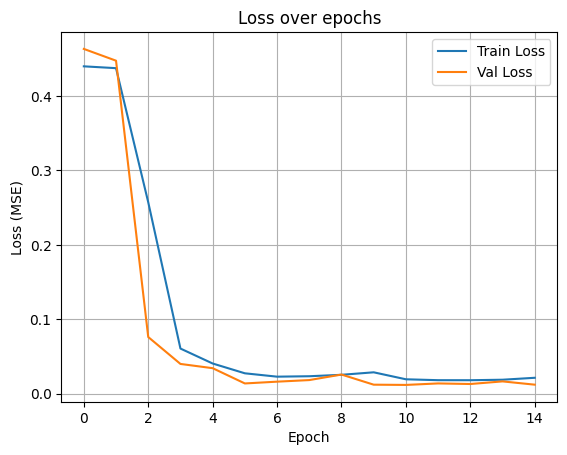

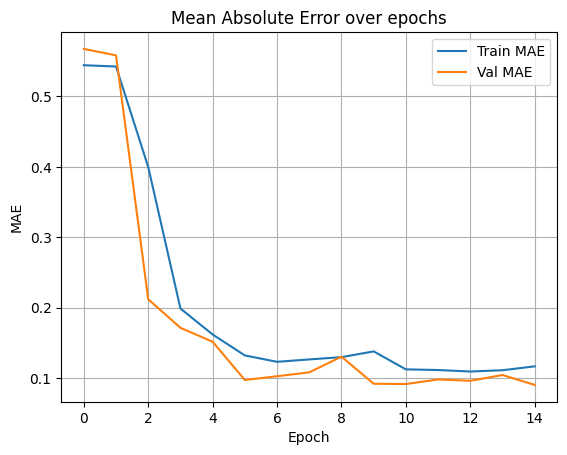

In [6]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error over epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
#Evaluacija na test skupu
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test MSE: 0.0146
Test MAE: 0.1027


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


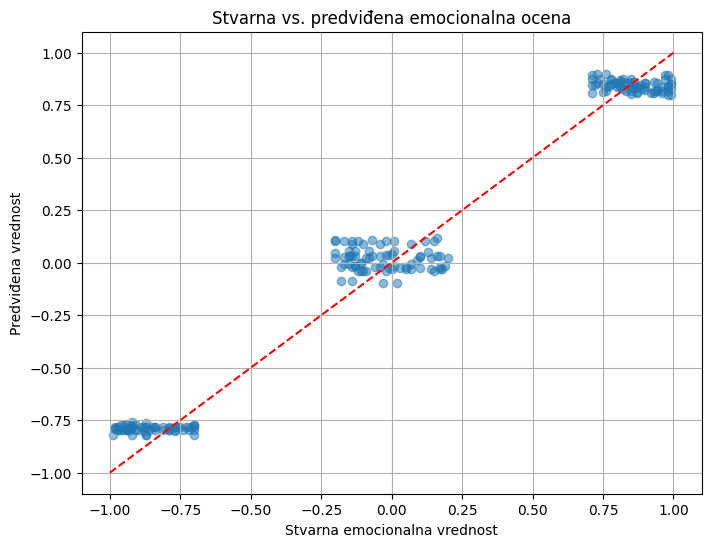

In [8]:
#stvarne vs predvidjene vrednosti scatter plot
# Predikcija
y_pred = model.predict(X_test).flatten()

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Stvarna emocionalna vrednost")
plt.ylabel("Predviđena vrednost")
plt.title("Stvarna vs. predviđena emocionalna ocena")
plt.grid(True)
plt.plot([-1, 1], [-1, 1], 'r--')  # dijagonala
plt.show()


In [14]:
# Testiranje  na novim recenicama

def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    pred = model.predict(padded)[0][0]
    return round(pred, 2)

# Primeri
examples = [
    "I hate everything about this.",
    "It was a beautiful moment.",
    "I'm not sure how I feel.",
    "Today was fine.",
    "Absolutely amazing!"
]

for text in examples:
    print(f"{text} → Predikcija: {predict_emotion(text)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
I hate everything about this. → Predikcija: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
It was a beautiful moment. → Predikcija: 0.009999999776482582
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
I'm not sure how I feel. → Predikcija: 0.009999999776482582
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Today was fine. → Predikcija: 0.009999999776482582
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Absolutely amazing! → Predikcija: 0.009999999776482582


Napredne ideje za prosirenje projekta

In [20]:
# Dodajemo Bidirectional sloj da model bolje
#razume kontekst iz obe strane rečenice (i unapred i unazad).

#🔹 Prednost: bolje hvatanje nijansi u rečenicama tipa: "I am not unhappy".

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Novi model sa Bidirectional LSTM
model_bi = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # regresija
])

model_bi.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_bi.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
#treniranj bidirectional modela:
history_bi = model_bi.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)



Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.4327 - mae: 0.5408 - val_loss: 0.4276 - val_mae: 0.5466
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3481 - mae: 0.4801 - val_loss: 0.1888 - val_mae: 0.3479
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1262 - mae: 0.2790 - val_loss: 0.0754 - val_mae: 0.2188
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0519 - mae: 0.1809 - val_loss: 0.0357 - val_mae: 0.1598
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0313 - mae: 0.1443 - val_loss: 0.0209 - val_mae: 0.1193
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0241 - mae: 0.1268 - val_loss: 0.0182 - val_mae: 0.1086
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0198 - mae: 0.1163 - val_loss: 0.0118 - val_mae: 0.0919
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0153 - mae: 0.1023 - val_loss: 0.0105 - val_mae: 0.0878
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.013

In [22]:
#Evaluacija bidirectional modela:

# Evaluacija
test_loss_bi, test_mae_bi = model_bi.evaluate(X_test, y_test, verbose=0)
print(f"Bidirectional LSTM - Test MSE: {test_loss_bi:.4f}")
print(f"Bidirectional LSTM - Test MAE: {test_mae_bi:.4f}")


Bidirectional LSTM - Test MSE: 0.0124
Bidirectional LSTM - Test MAE: 0.0958


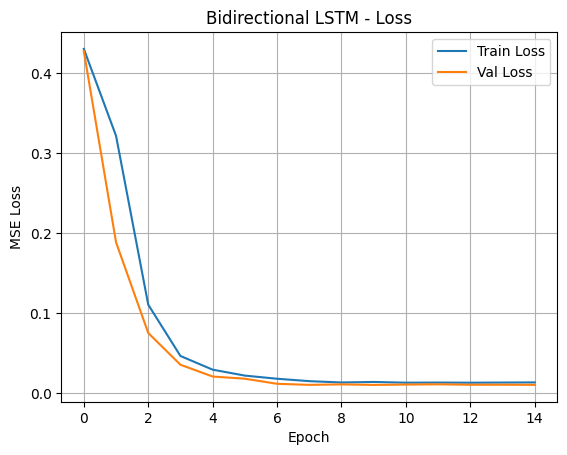

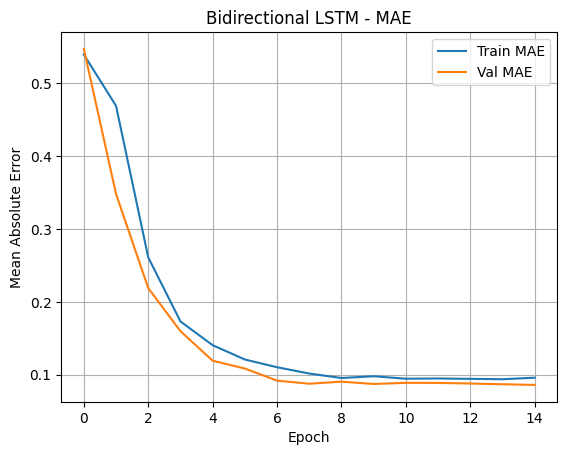

In [23]:
#vizuelizacija bidirectional modela:

# Loss
plt.plot(history_bi.history['loss'], label='Train Loss')
plt.plot(history_bi.history['val_loss'], label='Val Loss')
plt.title('Bidirectional LSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# MAE
plt.plot(history_bi.history['mae'], label='Train MAE')
plt.plot(history_bi.history['val_mae'], label='Val MAE')
plt.title('Bidirectional LSTM - MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()


Attention mehanizam
Dodavanje "attention" sloja koji pomaže modelu da fokusira pažnju na bitne delove rečenice.

📦 Možemo ručno definisati attention sloj ili koristiti keras-nlp ili transformers.

Primer jednostavnog attention wrappera možemo dodati kasnije ako želiš — ili možemo ići ka Transformer modelima.

3. Klasifikacija pored regresije (dual task)
Model može istovremeno da:

Predviđa tačnu vrednost emocije (regresija)

Predviđa klasu (negativno, neutralno, pozitivno)

➡️ Multitask learning – dodajemo još jedan izlazni sloj:

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))
x = Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM)(input_layer)
x = LSTM(64)(x)
x = Dropout(0.3)(x)

reg_output = Dense(1, activation='linear', name='regression')
class_output = Dense(3, activation='softmax', name='classification')  # 3 klase

model = Model(inputs=input_layer, outputs=[reg_output(x), class_output(x)])

model.compile(
    optimizer='adam',
    loss={'regression': 'mse', 'classification': 'sparse_categorical_crossentropy'},
    metrics={'regression': 'mae', 'classification': 'accuracy'}
)


4. Prikaz pogrešnih predikcija
Prikazati primere gde je razlika između stvarne i predviđene vrednosti najveća.

In [16]:
errors = np.abs(y_test - y_pred)
top_errors = np.argsort(errors)[-5:]

for i in top_errors:
    print(f"Tekst: {X_test[i]}")
    print(f"Stvarno: {y_test[i]}, Predikcija: {y_pred[i]:.2f}, Greška: {errors[i]:.2f}")
    print("------")


Tekst: [ 9 10  2 12  0  0  0  0  0  0  0  0  0  0  0]
Stvarno: -0.14, Predikcija: 0.10, Greška: 0.24
------
Tekst: [20  3  2 12  0  0  0  0  0  0  0  0  0  0  0]
Stvarno: -0.2, Predikcija: 0.04, Greška: 0.24
------
Tekst: [ 9 10  2 12  0  0  0  0  0  0  0  0  0  0  0]
Stvarno: -0.17, Predikcija: 0.10, Greška: 0.27
------
Tekst: [ 9 10 15 16  0  0  0  0  0  0  0  0  0  0  0]
Stvarno: -0.2, Predikcija: 0.10, Greška: 0.30
------
Tekst: [ 9 10  2 19  5  0  0  0  0  0  0  0  0  0  0]
Stvarno: -0.2, Predikcija: 0.11, Greška: 0.31
------
